This notebook is built upon the official Real-ESRGAN implementation.
Official Repository: https://github.com/xinntao/Real-ESRGAN
Authors: Xintao Wang et al.
This notebook only automates inference and evaluation on a custom underwater image dataset for research and educational purposes.
All model architecture and pretrained weights belong to their respective authors.

In [ ]:
import subprocess
import torch

print("=" * 60)
print("GPU INFORMATION")
print("=" * 60)

try:
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version', '--format=csv,noheader']
    ).decode('utf-8').strip()
    print(f"GPU Name / Memory / Driver: {gpu_info}")
except Exception as e:
    print(f"nvidia-smi not available: {e}")

print(f"\nPyTorch Version: {torch.__version__}")
print(f"Torch CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Count: {torch.cuda.device_count()}")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

print("=" * 60)

GPU INFORMATION
nvidia-smi not available: [Errno 2] No such file or directory: 'nvidia-smi'

PyTorch Version: 2.11.0+cpu
Torch CUDA Available: False


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=False)
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [ ]:
import os
from pathlib import Path

REPO_DIR = Path('/content/Real-ESRGAN')

if REPO_DIR.exists() and (REPO_DIR / '.git').exists():
    print(f"Repository already exists at {REPO_DIR}. Skipping clone.")
else:
    print("Cloning official Real-ESRGAN repository...")
    !git clone https://github.com/xinntao/Real-ESRGAN.git {REPO_DIR}
    print("Clone complete.")

os.chdir(REPO_DIR)
print(f"Current working directory: {os.getcwd()}")

Repository already exists at /content/Real-ESRGAN. Skipping clone.
Current working directory: /content/Real-ESRGAN


In [ ]:
import subprocess
import sys
import os

os.chdir('/content/Real-ESRGAN')

def run_cmd(cmd):
    print(f"\n>>> Running: {cmd}")
    result = subprocess.run(cmd, shell=True)
    if result.returncode != 0:
        print(f"WARNING: command exited with non-zero code ({result.returncode}): {cmd}")
    return result.returncode

try:
    run_cmd(f"{sys.executable} -m pip install -q basicsr")
    run_cmd(f"{sys.executable} -m pip install -q facexlib")
    run_cmd(f"{sys.executable} -m pip install -q gfpgan")
    run_cmd(f"{sys.executable} -m pip install -q -r requirements.txt")
    run_cmd(f"{sys.executable} setup.py develop")
except Exception as e:
    print(f"ERROR during installation: {e}")
    raise

# Compatibility patch: basicsr's degradations.py imports from a module path that
# was removed in newer torchvision versions.
try:
    import basicsr
    basicsr_path = os.path.dirname(basicsr.__file__)
    degrad_file = os.path.join(basicsr_path, 'data', 'degradations.py')
    if os.path.exists(degrad_file):
        with open(degrad_file, 'r') as f:
            content = f.read()
        if 'torchvision.transforms.functional_tensor' in content:
            content = content.replace(
                'from torchvision.transforms.functional_tensor import rgb_to_grayscale',
                'from torchvision.transforms.functional import rgb_to_grayscale'
            )
            with open(degrad_file, 'w') as f:
                f.write(content)
            print("Patched basicsr/data/degradations.py for torchvision compatibility.")
except Exception as e:
    print(f"Compatibility patch skipped (non-fatal): {e}")

print("\nAll dependencies installed.")


>>> Running: /usr/bin/python3 -m pip install -q basicsr

>>> Running: /usr/bin/python3 -m pip install -q facexlib

>>> Running: /usr/bin/python3 -m pip install -q gfpgan

>>> Running: /usr/bin/python3 -m pip install -q -r requirements.txt

>>> Running: /usr/bin/python3 setup.py develop

All dependencies installed.


In [ ]:
from pathlib import Path

WEIGHTS_DIR = Path('/content/Real-ESRGAN/weights')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHT_URL = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
WEIGHT_PATH = WEIGHTS_DIR / "RealESRGAN_x4plus.pth"

if WEIGHT_PATH.exists() and WEIGHT_PATH.stat().st_size > 0:
    print(f"Weights already exist at {WEIGHT_PATH}. Skipping download.")
else:
    print("Downloading official pretrained weights (RealESRGAN_x4plus.pth)...")
    !wget -q -O {str(WEIGHT_PATH)} {WEIGHT_URL}
    if not (WEIGHT_PATH.exists() and WEIGHT_PATH.stat().st_size > 0):
        raise RuntimeError("Failed to download pretrained weights. Check your internet connection.")
    print(f"Downloaded successfully to {WEIGHT_PATH}")

print(f"Weight file size: {WEIGHT_PATH.stat().st_size / (1024 * 1024):.2f} MB")

Weights already exist at /content/Real-ESRGAN/weights/RealESRGAN_x4plus.pth. Skipping download.
Weight file size: 63.94 MB


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')
DATASET_ROOT = DRIVE_ROOT / 'Dataset'

INPUT_DIR = DATASET_ROOT / 'gc_real'
REFERENCE_DIR = DATASET_ROOT / 'ce_real'
OUTPUT_DIR = DATASET_ROOT / 'enhanced_real_esrgan'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in [
    ("Input (gc_real)", INPUT_DIR),
    ("Reference (ce_real)", REFERENCE_DIR),
    ("Output (enhanced_real_esrgan)", OUTPUT_DIR),
]:
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name}: {path}  [{status}]")

if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input directory not found: {INPUT_DIR}. Check your Google Drive structure.")
if not REFERENCE_DIR.exists():
    raise FileNotFoundError(f"Reference directory not found: {REFERENCE_DIR}. Check your Google Drive structure.")

print("\nDataset paths configured successfully.")

Input (gc_real): /content/drive/MyDrive/Dataset/gc_real  [FOUND]
Reference (ce_real): /content/drive/MyDrive/Dataset/ce_real  [FOUND]
Output (enhanced_real_esrgan): /content/drive/MyDrive/Dataset/enhanced_real_esrgan  [FOUND]

Dataset paths configured successfully.


In [ ]:
from pathlib import Path

SUPPORTED_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(f for f in folder.iterdir() if f.is_file() and f.suffix.lower() in SUPPORTED_EXTENSIONS)

raw_images = list_images(INPUT_DIR)

print(f"Found {len(raw_images)} supported images in {INPUT_DIR}")
if len(raw_images) == 0:
    raise FileNotFoundError(f"No supported images found in {INPUT_DIR}")

for img in raw_images[:5]:
    print(f"  - {img.name}")
if len(raw_images) > 5:
    print(f"  ... and {len(raw_images) - 5} more")

Found 3 supported images in /content/drive/MyDrive/Dataset/gc_real
  - 616.png
  - 866.png
  - 880.png


In [ ]:
import subprocess

# Locate the exact degradations.py file that's failing and patch it directly
target_file = "/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py"

with open(target_file, 'r') as f:
    content = f.read()

if 'torchvision.transforms.functional_tensor' in content:
    content = content.replace(
        'from torchvision.transforms.functional_tensor import rgb_to_grayscale',
        'from torchvision.transforms.functional import rgb_to_grayscale'
    )
    with open(target_file, 'w') as f:
        f.write(content)
    print(f"Patched: {target_file}")
else:
    print("File already patched or import line not found — check manually.")

# Verify
with open(target_file, 'r') as f:
    print([l for l in f.readlines() if 'functional_tensor' in l or 'rgb_to_grayscale' in l][:3])

File already patched or import line not found — check manually.
['from torchvision.transforms.functional import rgb_to_grayscale\n', '        img_gray = rgb_to_grayscale(img, num_output_channels=1)\n']


In [ ]:
import sys
import time
import gc
import torch
import cv2
from tqdm.notebook import tqdm

if '/content/Real-ESRGAN' not in sys.path:
    sys.path.insert(0, '/content/Real-ESRGAN')

from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer


def build_upsampler(model_path, tile=400, half=True):
    # Builds the official RealESRGANer wrapper around the RRDBNet architecture.
    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
    use_cuda = torch.cuda.is_available()
    upsampler = RealESRGANer(
        scale=4,
        model_path=str(model_path),
        model=model,
        tile=tile,
        tile_pad=10,
        pre_pad=0,
        half=half and use_cuda,
        device='cuda' if use_cuda else 'cpu',
    )
    return upsampler


upsampler = build_upsampler(WEIGHT_PATH)
print("Real-ESRGAN model loaded successfully.")

processed_count = 0
skipped_count = 0
skipped_files = []
start_time = time.time()

for img_path in tqdm(raw_images, desc="Enhancing images"):
    output_path = OUTPUT_DIR / img_path.name

    if output_path.exists():
        # Avoid duplicate processing on re-runs.
        processed_count += 1
        continue

    try:
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError("cv2.imread returned None (corrupted or unreadable file).")

        output, _ = upsampler.enhance(img, outscale=4)
        cv2.imwrite(str(output_path), output)
        processed_count += 1

    except Exception as e:
        print(f"Skipping corrupted/unprocessable image '{img_path.name}': {e}")
        skipped_count += 1
        skipped_files.append(img_path.name)
        continue
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

elapsed_time = time.time() - start_time

# Free GPU memory now that inference is done.
del upsampler
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\nProcessing complete in {elapsed_time:.2f} seconds.")
print(f"Processed: {processed_count} | Skipped: {skipped_count}")
if skipped_files:
    print(f"Skipped files: {skipped_files}")

Real-ESRGAN model loaded successfully.


Enhancing images:   0%|          | 0/3 [00:00<?, ?it/s]

	Tile 1/8
	Tile 2/8
	Tile 3/8
	Tile 4/8
	Tile 5/8
	Tile 6/8
	Tile 7/8
	Tile 8/8
	Tile 1/8
	Tile 2/8
	Tile 3/8
	Tile 4/8
	Tile 5/8
	Tile 6/8
	Tile 7/8
	Tile 8/8

Processing complete in 1182.93 seconds.
Processed: 3 | Skipped: 0


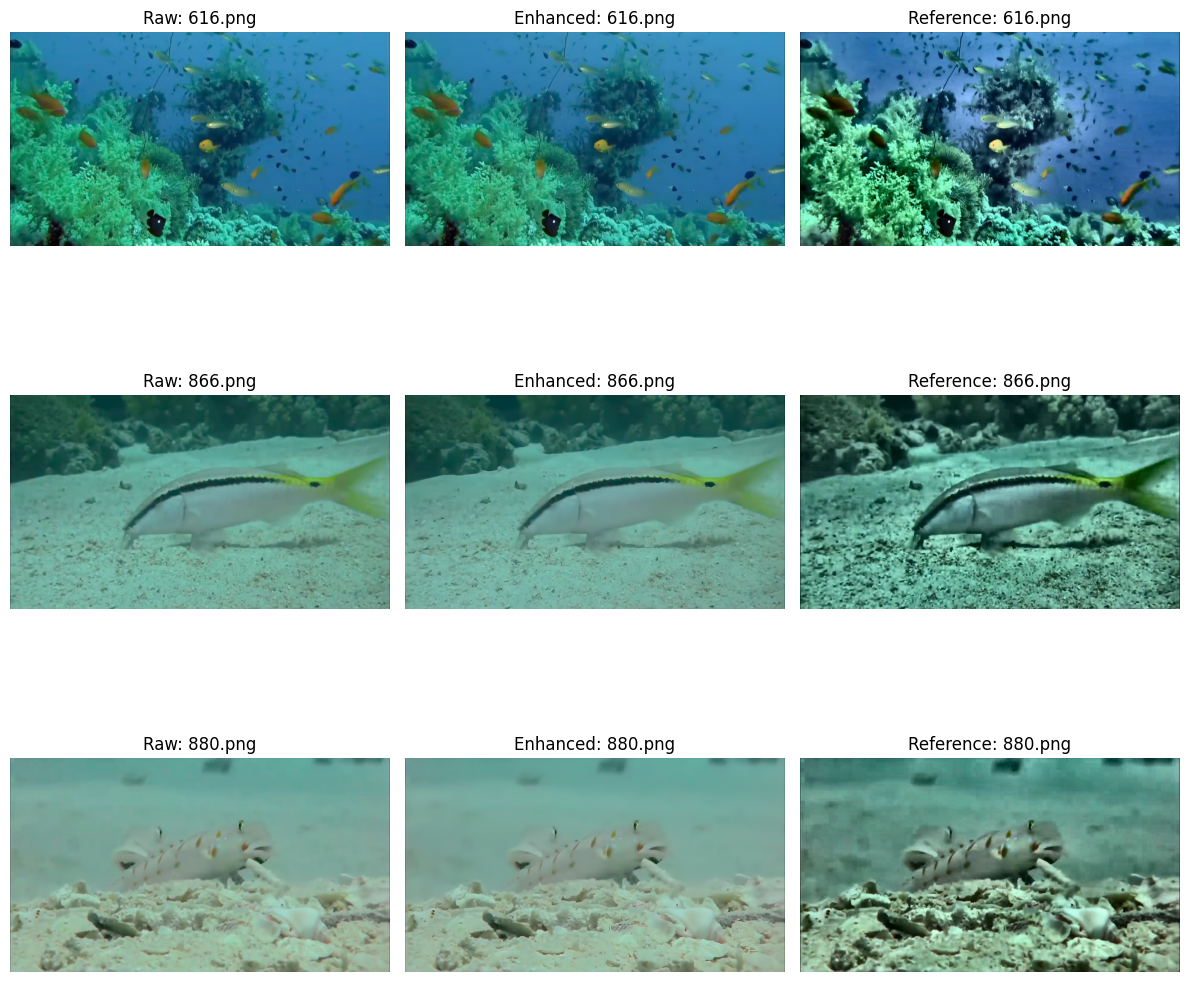

Displayed 3 raw / enhanced / reference comparisons.


In [ ]:
import matplotlib.pyplot as plt
import cv2


def load_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


enhanced_images = list_images(OUTPUT_DIR)
reference_images = list_images(REFERENCE_DIR)
reference_lookup = {f.stem: f for f in reference_images}

comparison_samples = []
for enh_path in enhanced_images:
    raw_path = INPUT_DIR / enh_path.name
    ref_path = reference_lookup.get(enh_path.stem)
    if raw_path.exists() and ref_path is not None:
        comparison_samples.append((raw_path, enh_path, ref_path))
    if len(comparison_samples) >= 5:
        break

if len(comparison_samples) == 0:
    print("No matching raw / enhanced / reference triplets found for visualization.")
else:
    n = len(comparison_samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes.reshape(1, 3)

    for i, (raw_p, enh_p, ref_p) in enumerate(comparison_samples):
        raw_img = load_rgb(raw_p)
        enh_img = load_rgb(enh_p)
        ref_img = load_rgb(ref_p)

        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"Raw: {raw_p.name}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(enh_img)
        axes[i, 1].set_title(f"Enhanced: {enh_p.name}")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(ref_img)
        axes[i, 2].set_title(f"Reference: {ref_p.name}")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Displayed {n} raw / enhanced / reference comparisons.")

In [ ]:
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

# ----------------------------------------------------------------
# PSNR / SSIM
# ----------------------------------------------------------------

def compute_psnr(enhanced_bgr, reference_bgr):
    h = min(enhanced_bgr.shape[0], reference_bgr.shape[0])
    w = min(enhanced_bgr.shape[1], reference_bgr.shape[1])
    e = cv2.resize(enhanced_bgr, (w, h))
    r = cv2.resize(reference_bgr, (w, h))
    return sk_psnr(r, e, data_range=255)


def compute_ssim(enhanced_bgr, reference_bgr):
    h = min(enhanced_bgr.shape[0], reference_bgr.shape[0])
    w = min(enhanced_bgr.shape[1], reference_bgr.shape[1])
    e = cv2.resize(enhanced_bgr, (w, h))
    r = cv2.resize(reference_bgr, (w, h))
    e_gray = cv2.cvtColor(e, cv2.COLOR_BGR2GRAY)
    r_gray = cv2.cvtColor(r, cv2.COLOR_BGR2GRAY)
    return sk_ssim(r_gray, e_gray, data_range=255)


# ----------------------------------------------------------------
# UIQM = c1*UICM + c2*UISM + c3*UIConM
# Panetta, Gao, Agaian (2016), "Human-Visual-System-Inspired
# Underwater Image Quality Measures", IEEE J. Oceanic Eng.
# ----------------------------------------------------------------

def _asymmetric_trimmed_stats(x, alpha_l=0.1, alpha_r=0.1):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    low = int(np.floor(alpha_l * n))
    high = int(np.floor(alpha_r * n))
    trimmed = x_sorted[low:n - high] if (n - high) > low else x_sorted
    mean = np.mean(trimmed)
    var = np.mean((trimmed - mean) ** 2)
    return mean, var


def _uicm(img_rgb):
    R = img_rgb[:, :, 0].astype(np.float64).flatten()
    G = img_rgb[:, :, 1].astype(np.float64).flatten()
    B = img_rgb[:, :, 2].astype(np.float64).flatten()

    RG = R - G
    YB = (R + G) / 2.0 - B

    rg_mean, rg_var = _asymmetric_trimmed_stats(RG)
    yb_mean, yb_var = _asymmetric_trimmed_stats(YB)

    return -0.0268 * np.sqrt(rg_mean ** 2 + yb_mean ** 2) + 0.1586 * np.sqrt(rg_var + yb_var)


def _eme(channel, block_size=8):
    h, w = channel.shape
    eme_val = 0.0
    n_blocks = 0
    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            block = channel[i:i + block_size, j:j + block_size]
            b_min = np.min(block) if np.min(block) != 0 else 1.0
            b_max = np.max(block) if np.max(block) != 0 else 1.0
            eme_val += np.log((b_max / b_min) + 1e-8)
            n_blocks += 1
    if n_blocks == 0:
        return 0.0
    return (2.0 / n_blocks) * abs(eme_val)


def _uism(img_rgb):
    R = img_rgb[:, :, 0].astype(np.float64)
    G = img_rgb[:, :, 1].astype(np.float64)
    B = img_rgb[:, :, 2].astype(np.float64)

    def sobel_mag(channel):
        sx = cv2.Sobel(channel, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(channel, cv2.CV_64F, 0, 1, ksize=3)
        return np.sqrt(sx ** 2 + sy ** 2)

    r_eme = _eme(sobel_mag(R) * R)
    g_eme = _eme(sobel_mag(G) * G)
    b_eme = _eme(sobel_mag(B) * B)

    lambda_r, lambda_g, lambda_b = 0.299, 0.587, 0.114
    return lambda_r * r_eme + lambda_g * g_eme + lambda_b * b_eme


def _uiconm(img_rgb, block_size=8):
    gray = cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float64)
    h, w = gray.shape
    logamee_val = 0.0
    n_blocks = 0
    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            block = gray[i:i + block_size, j:j + block_size]
            b_min = np.min(block)
            b_max = np.max(block)
            bot = (b_max + b_min) if (b_max + b_min) != 0 else 1e-8
            plip_val = (b_max - b_min) / bot
            plip_val = plip_val if plip_val > 0 else 1e-8
            logamee_val += plip_val * np.log(plip_val + 1e-8)
            n_blocks += 1
    if n_blocks == 0:
        return 0.0
    return abs((1.0 / n_blocks) * logamee_val)


def compute_uiqm(image_bgr):
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float64)
    c1, c2, c3 = 0.0282, 0.2953, 3.5753
    return c1 * _uicm(img_rgb) + c2 * _uism(img_rgb) + c3 * _uiconm(img_rgb)


# ----------------------------------------------------------------
# UCIQE = c1*sigma_c + c2*con_l + c3*mu_s
# Yang & Sowmya (2015), "An Underwater Color Image Quality
# Evaluation Metric", IEEE Trans. Image Process.
# ----------------------------------------------------------------

def compute_uciqe(image_bgr):
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float64)
    L, a, b = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    chroma = np.sqrt(a ** 2 + b ** 2)
    sigma_c = np.std(chroma)

    L_flat = np.sort(L.flatten())
    n = len(L_flat)
    top_idx = min(max(int(round(0.99 * n)) - 1, 0), n - 1)
    bot_idx = min(max(int(round(0.01 * n)), 0), n - 1)
    con_l = L_flat[top_idx] - L_flat[bot_idx]

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float64)
    mu_s = np.mean(hsv[:, :, 1])

    c1, c2, c3 = 0.4680, 0.2745, 0.2576
    return c1 * sigma_c + c2 * con_l + c3 * mu_s


print("Metric functions (PSNR, SSIM, UIQM, UCIQE) defined successfully.")

# ----------------------------------------------------------------
# Compute metrics for every enhanced / reference pair
# ----------------------------------------------------------------
results = []
for enh_path in tqdm(enhanced_images, desc="Computing metrics"):
    ref_path = reference_lookup.get(enh_path.stem)
    if ref_path is None:
        continue
    try:
        enh_img = cv2.imread(str(enh_path), cv2.IMREAD_COLOR)
        ref_img = cv2.imread(str(ref_path), cv2.IMREAD_COLOR)
        if enh_img is None or ref_img is None:
            print(f"Skipping metrics for '{enh_path.name}': could not read image.")
            continue

        h = min(enh_img.shape[0], ref_img.shape[0])
        w = min(enh_img.shape[1], ref_img.shape[1])
        enh_resized = cv2.resize(enh_img, (w, h))
        ref_resized = cv2.resize(ref_img, (w, h))

        results.append({
            'Image Name': enh_path.name,
            'PSNR': compute_psnr(enh_resized, ref_resized),
            'SSIM': compute_ssim(enh_resized, ref_resized),
            'UIQM': compute_uiqm(enh_resized),
            'UCIQE': compute_uciqe(enh_resized),
        })
    except Exception as e:
        print(f"Error computing metrics for '{enh_path.name}': {e}")
        continue

print(f"\nMetrics computed for {len(results)} images.")

Metric functions (PSNR, SSIM, UIQM, UCIQE) defined successfully.


Computing metrics:   0%|          | 0/3 [00:00<?, ?it/s]


Metrics computed for 3 images.


In [ ]:
import pandas as pd
from pathlib import Path

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values('Image Name').reset_index(drop=True)

display(results_df)

csv_path = Path('/content/results.csv')
csv_path_drive = DATASET_ROOT / 'results.csv'

results_df.to_csv(csv_path, index=False)
results_df.to_csv(csv_path_drive, index=False)

print(f"\nResults saved locally to: {csv_path}")
print(f"Results also saved to Drive: {csv_path_drive}")

,Image Name,PSNR,SSIM,UIQM,UCIQE
0,616.png,18.043005,0.783643,3.821399,93.757969
1,866.png,18.052735,0.678423,3.309541,64.166431
2,880.png,16.783917,0.775028,3.663101,45.571904



Results saved locally to: /content/results.csv
Results also saved to Drive: /content/drive/MyDrive/Dataset/results.csv


In [ ]:
if len(results_df) > 0:
    avg_psnr = results_df['PSNR'].mean()
    avg_ssim = results_df['SSIM'].mean()
    avg_uiqm = results_df['UIQM'].mean()
    avg_uciqe = results_df['UCIQE'].mean()

    print("=" * 50)
    print("OVERALL AVERAGE METRICS")
    print("=" * 50)
    print(f"Average PSNR  : {avg_psnr:.4f} dB")
    print(f"Average SSIM  : {avg_ssim:.4f}")
    print(f"Average UIQM  : {avg_uiqm:.4f}")
    print(f"Average UCIQE : {avg_uciqe:.4f}")
    print("=" * 50)
else:
    avg_psnr = avg_ssim = avg_uiqm = avg_uciqe = float('nan')
    print("No results available to compute averages.")

OVERALL AVERAGE METRICS
Average PSNR  : 17.6266 dB
Average SSIM  : 0.7457
Average UIQM  : 3.5980
Average UCIQE : 67.8321


In [ ]:
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

COMPARISON_DIR = Path('/content/comparison_images')
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

saved_figures = 0
for raw_p, enh_p, ref_p in comparison_samples:
    raw_img = load_rgb(raw_p)
    enh_img = load_rgb(enh_p)
    ref_img = load_rgb(ref_p)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_img); axes[0].set_title("Raw"); axes[0].axis('off')
    axes[1].imshow(enh_img); axes[1].set_title("Enhanced"); axes[1].axis('off')
    axes[2].imshow(ref_img); axes[2].set_title("Reference"); axes[2].axis('off')

    fig_path = COMPARISON_DIR / f"comparison_{raw_p.stem}.png"
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved_figures += 1

print(f"Saved {saved_figures} comparison figures to {COMPARISON_DIR}")

drive_comparison_dir = DATASET_ROOT / 'comparison_images'
drive_comparison_dir.mkdir(parents=True, exist_ok=True)
for f in COMPARISON_DIR.glob('*.png'):
    shutil.copy(f, drive_comparison_dir / f.name)

print(f"Copied comparison figures to Drive: {drive_comparison_dir}")

Saved 3 comparison figures to /content/comparison_images
Copied comparison figures to Drive: /content/drive/MyDrive/Dataset/comparison_images


In [ ]:
import shutil
from pathlib import Path

zip_base = '/content/enhanced_real_esrgan'
zip_path = shutil.make_archive(zip_base, 'zip', str(OUTPUT_DIR))
print(f"Created zip archive: {zip_path}")

drive_zip_path = DATASET_ROOT / 'enhanced_real_esrgan.zip'
shutil.copy(zip_path, drive_zip_path)
print(f"Copied zip archive to Drive: {drive_zip_path}")

zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"Zip file size: {zip_size_mb:.2f} MB")

Created zip archive: /content/enhanced_real_esrgan.zip
Copied zip archive to Drive: /content/drive/MyDrive/Dataset/enhanced_real_esrgan.zip
Zip file size: 41.25 MB


In [ ]:
print("=" * 60)
print("FINAL EXECUTION SUMMARY")
print("=" * 60)
print(f"Total Images Found        : {len(raw_images)}")
print(f"Processed Images          : {processed_count}")
print(f"Skipped Images            : {skipped_count}")
print(f"Processing Time           : {elapsed_time:.2f} seconds")
print("-" * 60)
print(f"Average PSNR              : {avg_psnr:.4f} dB")
print(f"Average SSIM              : {avg_ssim:.4f}")
print(f"Average UIQM              : {avg_uiqm:.4f}")
print(f"Average UCIQE             : {avg_uciqe:.4f}")
print("-" * 60)
print(f"Enhanced Output Folder    : {OUTPUT_DIR}")
print(f"CSV Location (local)      : {csv_path}")
print(f"CSV Location (Drive)      : {csv_path_drive}")
print(f"Zip Location (local)      : {zip_path}")
print(f"Zip Location (Drive)      : {drive_zip_path}")
print(f"Comparison Images (local) : {COMPARISON_DIR}")
print(f"Comparison Images (Drive) : {drive_comparison_dir}")
print("=" * 60)
print("\nPipeline completed successfully. All outputs saved.")

FINAL EXECUTION SUMMARY
Total Images Found        : 3
Processed Images          : 3
Skipped Images            : 0
Processing Time           : 1182.93 seconds
------------------------------------------------------------
Average PSNR              : 17.6266 dB
Average SSIM              : 0.7457
Average UIQM              : 3.5980
Average UCIQE             : 67.8321
------------------------------------------------------------
Enhanced Output Folder    : /content/drive/MyDrive/Dataset/enhanced_real_esrgan
CSV Location (local)      : /content/results.csv
CSV Location (Drive)      : /content/drive/MyDrive/Dataset/results.csv
Zip Location (local)      : /content/enhanced_real_esrgan.zip
Zip Location (Drive)      : /content/drive/MyDrive/Dataset/enhanced_real_esrgan.zip
Comparison Images (local) : /content/comparison_images
Comparison Images (Drive) : /content/drive/MyDrive/Dataset/comparison_images

Pipeline completed successfully. All outputs saved.


In [ ]:
print("=" * 60)
print("FINAL EXECUTION SUMMARY")
print("=" * 60)
print(f"Total Images Found        : {len(raw_images)}")
print(f"Processed Images          : {processed_count}")
print(f"Skipped Images            : {skipped_count}")
print(f"Processing Time           : {elapsed_time:.2f} seconds")
print("-" * 60)
print(f"Average PSNR              : {avg_psnr:.4f} dB")
print(f"Average SSIM              : {avg_ssim:.4f}")
print(f"Average UIQM              : {avg_uiqm:.4f}")
print(f"Average UCIQE             : {avg_uciqe:.4f}")
print("-" * 60)
print(f"Enhanced Output Folder    : {OUTPUT_DIR}")
print(f"CSV Location (local)      : {csv_path}")
print(f"CSV Location (Drive)      : {csv_path_drive}")
print(f"Zip Location (local)      : {zip_path}")
print(f"Zip Location (Drive)      : {drive_zip_path}")
print(f"Comparison Images (local) : {COMPARISON_DIR}")
print(f"Comparison Images (Drive) : {drive_comparison_dir}")
print("=" * 60)
print("\nPipeline completed successfully. All outputs saved.")

FINAL EXECUTION SUMMARY
Total Images Found        : 3
Processed Images          : 3
Skipped Images            : 0
Processing Time           : 1182.93 seconds
------------------------------------------------------------
Average PSNR              : 17.6266 dB
Average SSIM              : 0.7457
Average UIQM              : 3.5980
Average UCIQE             : 67.8321
------------------------------------------------------------
Enhanced Output Folder    : /content/drive/MyDrive/Dataset/enhanced_real_esrgan
CSV Location (local)      : /content/results.csv
CSV Location (Drive)      : /content/drive/MyDrive/Dataset/results.csv
Zip Location (local)      : /content/enhanced_real_esrgan.zip
Zip Location (Drive)      : /content/drive/MyDrive/Dataset/enhanced_real_esrgan.zip
Comparison Images (local) : /content/comparison_images
Comparison Images (Drive) : /content/drive/MyDrive/Dataset/comparison_images

Pipeline completed successfully. All outputs saved.
